# LOAD LIBRARIES

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [22]:
START_DATE, END_DATE = '2023-11-08', '2024-07-25' # Wheat
TARGET_FLUX = 'FN2O'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = True
ADD_ID = False
UNDERSAMPLE = True
PERMUTATION_SEL = False
RFE_SEL = True

# LOAD DATA

In [23]:
data_main = fluxes = load_parquet(filepath=r"../81.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE]

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

data_main

Loaded .parquet file ../81.1_GapFillingDataset.parquet (0.320 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,prec,ta,timesince_prec,vpd,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,1.991226,-0.238835,1.752390,B,certain,0.0,5.333333,12.0,0.180179,...,-1.485105,-1.116706,-1.152150,-0.275176,-0.379151,2.956382,-1.564360,0.573172,-0.047840,-0.181710,-0.177446,0.052573,-1.360142,-0.071378,0.477293
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,5.966667,13.0,0.210078,...,-1.413669,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.022171,0.720981,-0.202111,-0.048345,0.008988,0.015635,-1.939471,0.000852,0.241896
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,5.833333,14.0,0.209377,...,-1.482971,-1.423575,-1.251268,0.154263,0.054827,2.845686,-1.730258,0.304878,0.755972,-0.137978,0.079340,0.129646,-0.687567,0.201061,0.512755
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,2.026159,-0.206519,1.819640,B,certain,0.0,5.866667,15.0,0.212335,...,-1.613288,-1.456775,-1.194985,0.190084,0.205121,2.216312,-1.685342,0.385222,0.331593,-0.220338,-0.022307,0.288816,-0.600509,0.215442,0.568651
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,5.766667,16.0,0.210251,...,-1.522183,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.500100,0.629110,0.868842,-0.175981,-0.027153,0.167790,-0.600174,0.027040,0.576383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-25 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.562339,4.946882,None,None,0.0,16.166667,128.0,0.246013,...,0.312428,1.979258,0.117887,0.470140,1.934095,0.069588,-0.781542,-0.944345,-0.828950,-0.099631,0.205294,-0.326433,-0.285875,0.167037,-0.173701
2024-07-25 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.656828,4.852393,None,None,0.0,15.766667,129.0,0.218872,...,-0.248039,1.702703,0.001131,0.240362,1.779158,-0.057751,-0.904521,-1.299068,-1.184607,-0.106046,0.163649,-0.343612,-0.287530,-0.037435,-0.212412
2024-07-25 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.671307,4.837914,None,None,0.0,15.700000,130.0,0.207221,...,0.007799,1.272358,-0.123926,0.233171,1.737272,-0.048307,-1.044708,-1.119899,-1.157502,-0.137013,0.089801,-0.460830,-0.300689,0.009702,-0.200432


# CLEAN DATA

In [24]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data_main = data_main[data_main[TARGET].notna()].copy()

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data_main.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data_main.drop(columns=to_drop, inplace=True)

data_main

The target variable is FN2O_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 4.583804143126177


,NEE_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,prec,ta,timesince_prec,vpd,ts_0.05_gfXG,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:45:00,NaN,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,5.966667,13.0,0.210078,6.817496,...,-1.413669,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.022171,0.720981,-0.202111,-0.048345,0.008988,0.015635,-1.939471,0.000852,0.241896
2023-11-08 01:15:00,NaN,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,5.833333,14.0,0.209377,6.969578,...,-1.482971,-1.423575,-1.251268,0.154263,0.054827,2.845686,-1.730258,0.304878,0.755972,-0.137978,0.079340,0.129646,-0.687567,0.201061,0.512755
2023-11-08 02:15:00,NaN,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,5.766667,16.0,0.210251,7.089032,...,-1.522183,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.500100,0.629110,0.868842,-0.175981,-0.027153,0.167790,-0.600174,0.027040,0.576383
2023-11-08 03:15:00,NaN,-3.270484,NaN,0.070120,-3.270484,1.991226,-0.230492,1.760734,B,certain,0.0,5.400000,18.0,0.212734,7.258470,...,-1.514255,-1.743717,-1.250376,-0.069672,0.010304,0.609105,-1.514331,0.425002,1.042137,-0.005165,-0.065745,0.055501,0.100861,0.057352,0.449444
2023-11-08 04:15:00,NaN,NaN,NaN,-0.545573,NaN,1.818380,-0.152503,1.665877,B,certain,0.0,4.633333,20.0,0.174974,7.059120,...,-1.212816,-1.319282,-0.813456,-0.114923,-0.589170,0.650526,-1.214557,0.525693,1.072204,0.251217,0.064532,0.108497,0.323842,0.325964,0.776480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23 20:15:00,4.628327,NaN,4.628327,0.586950,NaN,4.628327,1.471090,6.099417,B,certain,0.0,21.516667,29.0,0.759515,22.421481,...,0.852222,1.735926,0.600000,0.655556,0.622224,0.198150,-0.553513,-0.938438,-1.631175,-0.131180,-0.291483,-0.705238,-0.078957,-0.378195,-0.613143
2024-07-23 21:45:00,7.550813,26.565978,7.550813,0.059754,NaN,7.550813,-1.602951,5.947863,B,uncertain,0.0,20.890000,32.0,0.624487,21.820739,...,0.298889,1.646667,0.510741,0.575927,0.808153,0.273335,-0.468222,-0.990004,-1.575818,-0.153802,-0.250246,-0.647301,-0.053031,-0.307722,-0.586090
2024-07-23 22:45:00,6.208043,22.870423,6.208043,1.018285,NaN,6.208043,-0.325577,5.882467,B,uncertain,0.0,20.613333,34.0,0.576078,21.545925,...,-0.038889,1.417407,0.461111,0.455189,0.860374,0.278150,-0.399088,-0.994408,-1.534722,-0.170135,-0.255927,-0.654275,-0.036732,-0.269136,-0.563984


# SELECT FEATURES

In [25]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 20
# path = 'temp/ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'n_decay_timed',
# 'timesince_fert', 
# 'timesince_soil_preparation',
# 'wfps_0.3_roll48hmean',
# 'wfps_0.3_diff48h',
# 'ts_0.3_roll48hmean',
# 'flux_gpp_roll48hsum'
# ]


# Keep only the best feature set
data = data_main[selected_features + [TARGET]].copy()

data

,Reco_U50_reddyproc,n_decay_linear,n_decay_logistic,n_decay_lognormal,n_decay_timed,timesince_fert,Reco_U50_reddyproc_roll24hsum,ts_0.05_gfXG_lag6h_roll12hmean,ts_0.15_gfXG_lag48h_roll12hmean,ts_0.3_gfXG_lag48h_roll24hmean,wfps_0.15_gfXG_lag48h_roll24hmean,wfps_0.3_gfXG_lag24h_roll24hmean,wfps_0.3_gfXG_lag48h_roll24hmean,ts_0.05_gfXG_diff6h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,
2023-11-08 00:45:00,1.832376,0.0,0.0,0.983564,29.0,22.0,35.382931,9.726170,10.202282,10.864892,52.919161,35.794196,37.921162,-2.150213,0.100302
2023-11-08 01:15:00,1.815404,0.0,0.0,0.980476,29.0,22.0,37.198334,9.715123,10.200916,10.802249,52.900779,35.740501,37.899198,-1.557238,0.239428
2023-11-08 02:15:00,1.806944,0.0,0.0,0.974334,29.0,22.0,40.824918,9.681869,10.187220,10.678551,52.852301,35.667729,37.833866,-1.159053,0.358358
2023-11-08 03:15:00,1.760734,0.0,0.0,0.968238,29.0,22.0,44.379940,9.563946,10.224625,10.552943,52.805531,35.599306,37.772543,-0.473987,0.070120
2023-11-08 04:15:00,1.665877,0.0,0.0,0.962185,29.0,22.0,47.794042,9.440622,10.330484,10.456640,52.764818,35.537506,37.722029,-0.531303,-0.545573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23 20:15:00,6.099417,0.0,0.0,0.000000,0.0,30.0,290.642735,20.640077,21.595401,20.478341,49.066442,32.177715,31.657421,-0.997407,0.586950
2024-07-23 21:45:00,5.947863,0.0,0.0,0.000000,0.0,30.0,290.875423,21.119459,21.831481,20.481065,49.026512,32.297440,31.625056,-2.089259,0.059754
2024-07-23 22:45:00,5.882467,0.0,0.0,0.000000,0.0,30.0,291.105352,21.462793,21.968981,20.482577,48.998208,32.376470,31.603105,-2.255184,1.018285


# IMBALANCE HANDLING

## UNDER SAMPLING

Undersampling target data below: 0.31358878


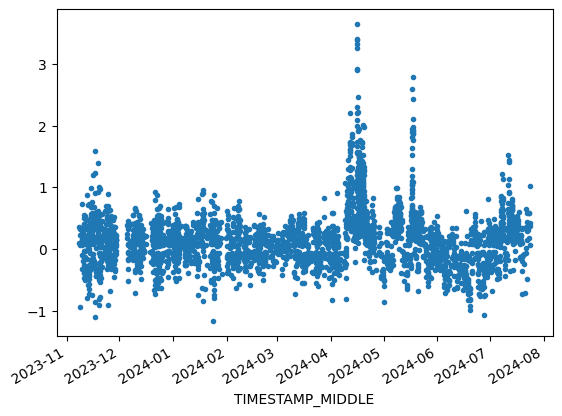

In [26]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.')
    plt.show()

## LOG TRANSFORMATION

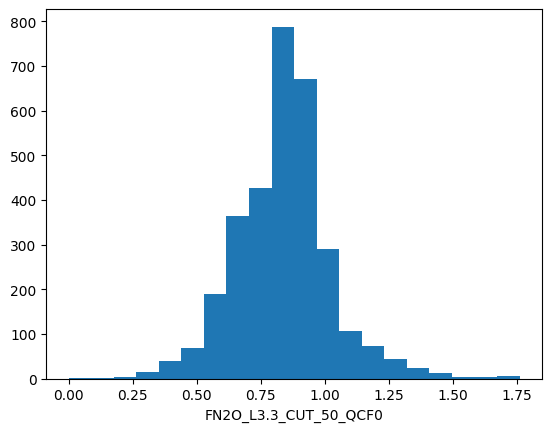

,Reco_U50_reddyproc,n_decay_linear,n_decay_logistic,n_decay_lognormal,n_decay_timed,timesince_fert,Reco_U50_reddyproc_roll24hsum,ts_0.05_gfXG_lag6h_roll12hmean,ts_0.15_gfXG_lag48h_roll12hmean,ts_0.3_gfXG_lag48h_roll24hmean,wfps_0.15_gfXG_lag48h_roll24hmean,wfps_0.3_gfXG_lag24h_roll24hmean,wfps_0.3_gfXG_lag48h_roll24hmean,ts_0.05_gfXG_diff6h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,
2023-11-08 00:45:00,1.832376,0.0,0.0,0.983564,29.0,22.0,35.382931,9.726170,10.202282,10.864892,52.919161,35.794196,37.921162,-2.150213,0.819045
2023-11-08 02:15:00,1.806944,0.0,0.0,0.974334,29.0,22.0,40.824918,9.681869,10.187220,10.678551,52.852301,35.667729,37.833866,-1.159053,0.926791
2023-11-08 11:15:00,2.246274,0.0,0.0,0.921023,29.0,22.0,72.490848,7.601667,11.270644,10.404063,52.503194,35.229081,37.312852,1.237949,0.209136
2023-11-08 11:45:00,2.297578,0.0,0.0,0.918162,29.0,22.0,74.788427,7.493805,11.259924,10.394172,52.477896,35.233762,37.241432,1.639059,0.802914
2023-11-08 12:15:00,2.349357,0.0,0.0,0.915311,29.0,22.0,77.137784,7.383656,11.192845,10.385619,52.450836,35.239350,37.166981,1.354692,0.915797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-23 20:15:00,6.099417,0.0,0.0,0.000000,0.0,30.0,290.642735,20.640077,21.595401,20.478341,49.066442,32.177715,31.657421,-0.997407,1.013410
2024-07-23 21:45:00,5.947863,0.0,0.0,0.000000,0.0,30.0,290.875423,21.119459,21.831481,20.481065,49.026512,32.297440,31.625056,-2.089259,0.801008
2024-07-23 22:45:00,5.882467,0.0,0.0,0.000000,0.0,30.0,291.105352,21.462793,21.968981,20.482577,48.998208,32.376470,31.603105,-2.255184,1.158865


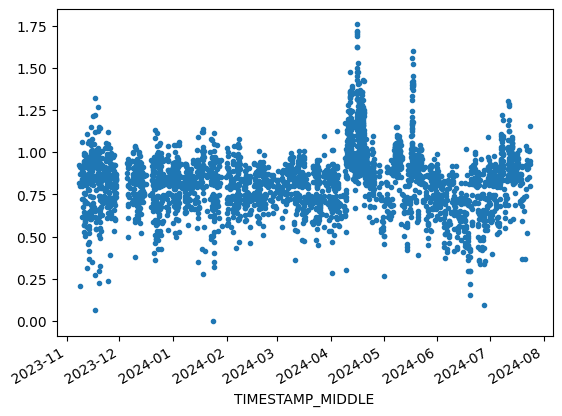

In [27]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

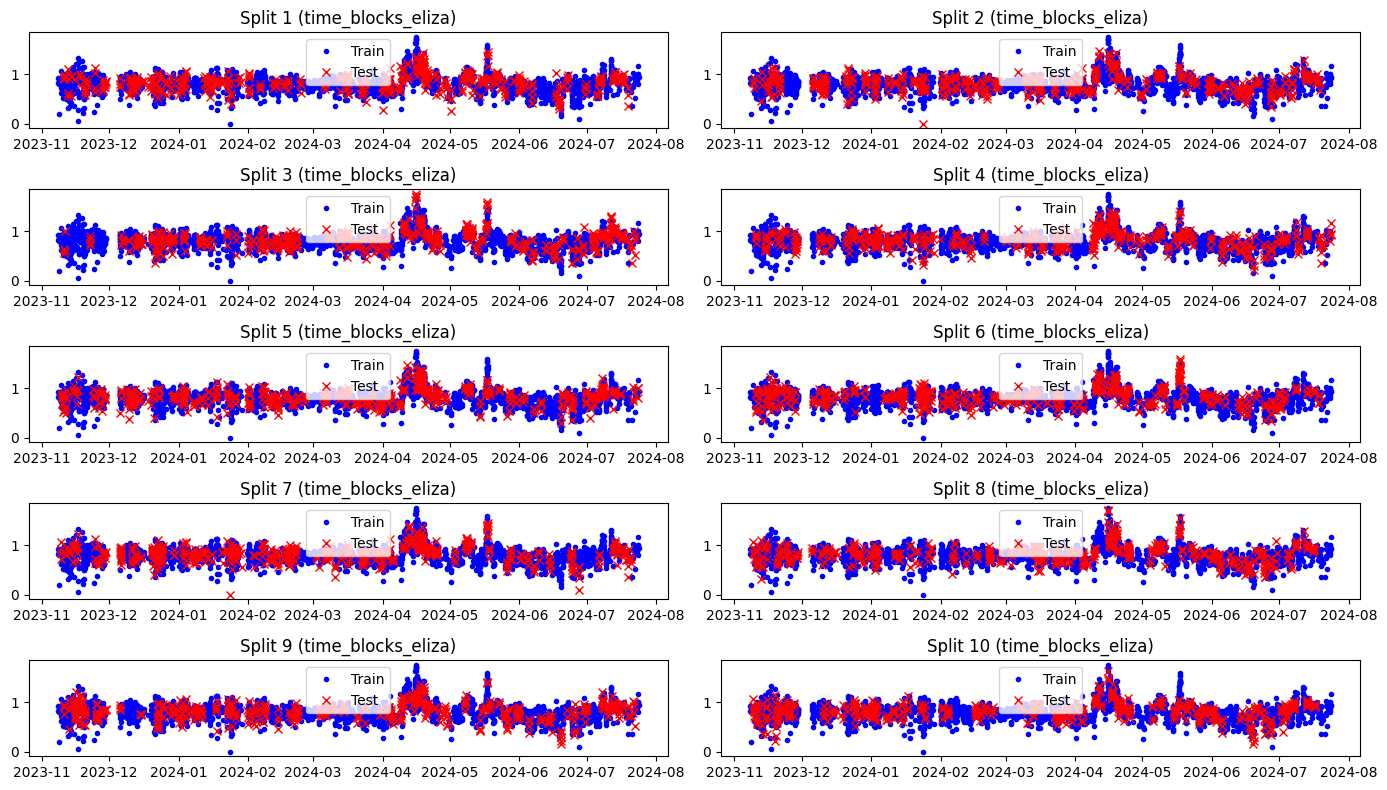

In [28]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = mean_nan_size, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits
    
if CROSSVAL_SPLIT == 'custom_time_blocks':
    def create_splits(X, y, n_folds=5, test_fraction=0.2, block_duration='1D',
                    min_gap='6D', buffer_gap='1D', seed=None):
        """
        Time-block CV with buffer and min_gap enforcement, allowing partial blocks to match test_fraction.
        """
        if seed is not None:
            np.random.seed(seed)

        total_rows = len(X)
        total_test_target = int(total_rows * test_fraction)
        all_times = X.index
        block_dur = pd.to_timedelta(block_duration)
        min_gap_dur = pd.to_timedelta(min_gap)
        buffer_gap_dur = pd.to_timedelta(buffer_gap)

        # Generate all possible block start times
        possible_starts = all_times[(all_times + block_dur) <= all_times[-1]]
        splits = []

        for fold in range(n_folds):
            test_indices = set()
            buffer_indices = set()
            selected_blocks = []

            shuffled_starts = np.random.permutation(possible_starts)

            for start_time in shuffled_starts:
                end_time = start_time + block_dur
                buffer_start = start_time - buffer_gap_dur
                buffer_end = end_time + buffer_gap_dur

                # Enforce min_gap between selected test blocks
                if any(abs(pd.Timedelta(start_time - sel).total_seconds()) < min_gap_dur.total_seconds()
                    for sel in selected_blocks):
                    continue

                block_mask = (all_times >= start_time) & (all_times < end_time)
                buffer_mask = (all_times >= buffer_start) & (all_times < buffer_end)

                block_idx = np.where(block_mask)[0]
                buffer_idx = np.where(buffer_mask)[0]

                if len(block_idx) == 0:
                    continue

                # Allow trimming final block if needed
                remaining = total_test_target - len(test_indices)
                if remaining <= 0:
                    break
                if len(block_idx) > remaining:
                    block_idx = block_idx[:remaining]

                # Check again for overlap with buffer
                if any(i in buffer_indices for i in block_idx):
                    continue

                test_indices.update(block_idx)
                buffer_indices.update(buffer_idx)
                selected_blocks.append(start_time)

                if len(test_indices) >= total_test_target:
                    break

            train_indices = sorted(set(range(total_rows)) - test_indices - buffer_indices)
            splits.append((np.array(train_indices), np.array(sorted(test_indices))))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [ ]:
# Convert cross-val splits into PredefinedSplit format to be able to use them in GridSearchCV
test_fold = np.full(len(data), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(cross_val_splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
predefined_cv = PredefinedSplit(test_fold)

param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 300, 500], # Similar to XGBoost
        'max_depth': [3, 5, 10, 15], # Controls tree depth
        'min_samples_split': [2, 5, 10], # Similar to min_child_weight
        'min_samples_leaf': [1, 3, 5], # Controls leaf size
        'max_features': [0.4, 0.6, 0.8, 1.0], # Similar to colsample_bytree
    },
    'XGBoost': {
        'n_estimators': [50, 100, 300, 500],
        'gamma': [0, 0.2, 0.4],
        'max_depth': [3, 5, 10, 15],
        'learning_rate': [0.001, 0.005, 0.01, 0.05],
        'subsample': [0.65, 0.75, 1],
        'colsample_bytree': [0.4, 0.6, 0.8, 1],
        'min_child_weight': [2, 5, 10]
    }
}

model_class = RandomForestRegressor if MODEL_TYPE == 'RandomForest' else XGBRegressor
param_grid = param_grids[MODEL_TYPE]
model = model_class(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=predefined_cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(data[selected_features], data[TARGET])

print("Best Parameters:", grid_search.best_params_)

# EXPORT 

In [ ]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(grid_search.best_params_, f)

# **End of notebook**

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")